In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
import patsy
import networkx as nx
print("done")

done


# Assignment 2 - Complex Systems in Bioinformatics
**Authors: Gress (), Prakash ()**

## Problem 1 - Dataset Mathematic Marks

In [89]:
marks_df = pd.read_csv("./math_marks.csv", index_col='student_id')
print(marks_df.dtypes)
MARKS_COLS = ['mechanics', 'vectors', 'algebra', 'analysis', 'statistics']
marks_df.describe()

mechanics     int64
vectors       int64
algebra       int64
analysis      int64
statistics    int64
dtype: object


,mechanics,vectors,algebra,analysis,statistics
count,88.000000,88.000000,88.000000,88.000000,88.000000
mean,38.965909,50.590909,50.602273,46.681818,42.306818
std,17.483949,13.146947,10.624781,14.845213,17.255589
min,0.000000,9.000000,15.000000,9.000000,9.000000
25%,30.000000,42.000000,45.000000,35.750000,31.000000
50%,41.500000,51.000000,50.000000,49.000000,40.000000
75%,49.250000,60.000000,57.250000,57.000000,51.500000
max,77.000000,82.000000,80.000000,70.000000,81.000000


**(B)** Pairwise scatter plot. Dependencies?

We observe signs of linear dependencies, ex. algebra + statistics

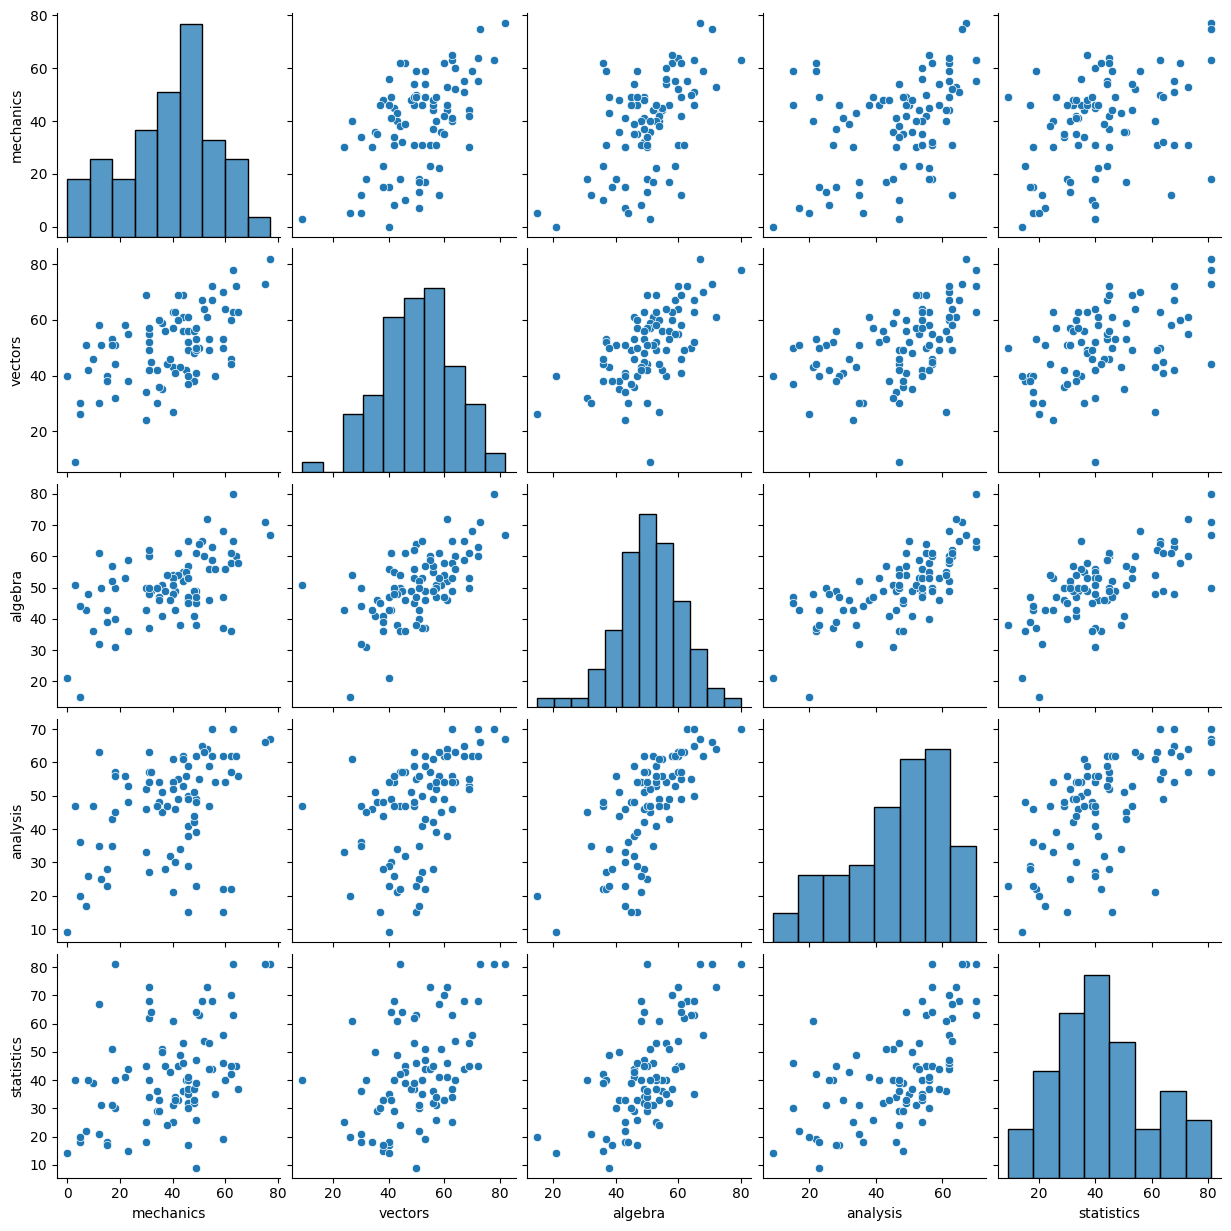

In [90]:
sns.pairplot(marks_df)
plt.savefig("img/P1B_pairplot")
plt.show()

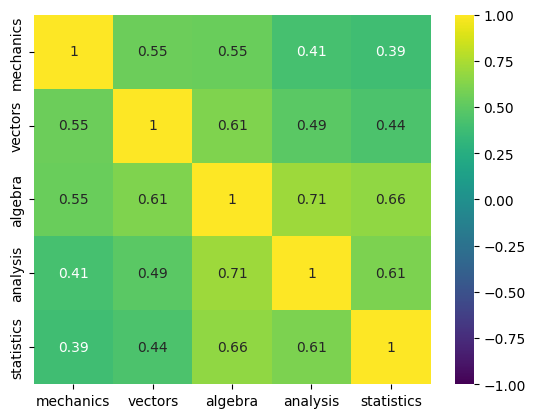

In [91]:
corr_mx = marks_df.corr()
sns.heatmap(corr_mx, annot=True, vmin=-1, vmax=1, cmap='viridis')
plt.savefig("img/P1C_heatmap_raw")
plt.show()

**(D)** Take diagonal of inverse correlation matrix and calculate S scores.

In [92]:
corr_mx_inv = np.linalg.inv(corr_mx)
D = np.diag(corr_mx_inv)
S = [(d-1)/d for d in D]
S

[0.3756076664277902,
 0.4447845479846339,
 0.671171841027019,
 0.5408626171831167,
 0.4793425958671895]

In [93]:

formula1 =  "mechanics ~ vectors+algebra+analysis+statistics"
formula2 =  'vectors ~ mechanics+algebra+analysis+statistics'
formula3 =  'algebra ~ mechanics+vectors+analysis+statistics'
formula4 =  'analysis ~ mechanics+algebra+vectors+statistics'
formula5 =  'statistics ~ mechanics+algebra+analysis+vectors'
formulas = [formula1, formula2, formula3, formula4, formula5]

R_qdr = {}
for formula in formulas:
    y, X = patsy.dmatrices(formula, marks_df, return_type = 'dataframe')
    model = LinearRegression().fit(X,y)
    R_qdr[formula] = model.score(X,y)

R_qdr

{'mechanics ~ vectors+algebra+analysis+statistics': 0.3756076664277902,
 'vectors ~ mechanics+algebra+analysis+statistics': 0.44478454798463396,
 'algebra ~ mechanics+vectors+analysis+statistics': 0.6711718410270189,
 'analysis ~ mechanics+algebra+vectors+statistics': 0.5408626171831167,
 'statistics ~ mechanics+algebra+analysis+vectors': 0.4793425958671893}

**(F)** Covarience matrix and its inverse. Rescale to 1 on diagonal and others like $-(p_{ij} / \sqrt{(p_{ii}p_{ij})})$

In [94]:
cov_mx = marks_df.cov()
cov_mx_inv = np.linalg.inv(cov_mx)
K = np.zeros_like(cov_mx_inv)
for i in range(K.shape[0]):
    for j in range(K.shape[1]):
        if i != j:
            p_ij = cov_mx_inv[i,j]
            p_ii = cov_mx_inv[i,i]
            p_jj = cov_mx_inv[j,j]
            K[i,j] = -1* p_ij/np.sqrt(p_ii*p_jj)
        else:
            K[i,j]=1

pd.DataFrame(K)

,0,1,2,3,4
0,1.000000,0.328463,0.229244,-0.000712,0.025509
1,0.328463,1.000000,0.281601,0.077830,0.019969
2,0.229244,0.281601,1.000000,0.431771,0.356736
3,-0.000712,0.077830,0.431771,1.000000,0.252777
4,0.025509,0.019969,0.356736,0.252777,1.000000


**(G)** Fit `mechanics ~ algebra + analysis + statistics` and `vectors ~ algerba + analysis + statistics` and calculate correlation between the *residuals*.

In [95]:
def fit_and_correlate(formulas):
    residuals = pd.DataFrame()
    for formula in formulas:
        y, X = patsy.dmatrices(formula, marks_df, return_type = 'dataframe')
        model = LinearRegression().fit(X,y)
        residuals[formula] = y - model.predict(X)

    return residuals.corr()

In [96]:
formula1 =  "mechanics ~ algebra + analysis + statistics"
formula2 =  'vectors ~ algebra + analysis + statistics'
formulas = [formula1, formula2]

fit_and_correlate(formulas)

,mechanics ~ algebra + analysis + statistics,vectors ~ algebra + analysis + statistics
mechanics ~ algebra + analysis + statistics,1.000000,0.328463
vectors ~ algebra + analysis + statistics,0.328463,1.000000


**(H)** Repeat with response variables `mechanics, algebra`, `mechanics, analysis`, `mechanics, statistics`. The three remaining vars are then explanatory. Look at corr between all residuals and compare with K. 

In [97]:
formula1 =  "mechanics ~ vectors + analysis + statistics"
formula2 =  'algebra ~ vectors + analysis + statistics'

fit_and_correlate([formula1, formula2])





,mechanics ~ vectors + analysis + statistics,algebra ~ vectors + analysis + statistics
mechanics ~ vectors + analysis + statistics,1.000000,0.229244
algebra ~ vectors + analysis + statistics,0.229244,1.000000


In [98]:
formula3 =  "mechanics ~ vectors + algebra + statistics"
formula4 =  'analysis ~ vectors + algebra + statistics'
fit_and_correlate([formula3, formula4])


,mechanics ~ vectors + algebra + statistics,analysis ~ vectors + algebra + statistics
mechanics ~ vectors + algebra + statistics,1.000000,-0.000712
analysis ~ vectors + algebra + statistics,-0.000712,1.000000


In [99]:
formula5 =  "mechanics ~ vectors + algebra + analysis"
formula6 =  'statistics ~ vectors + algebra + analysis'
fit_and_correlate([formula5, formula6])

,mechanics ~ vectors + algebra + analysis,statistics ~ vectors + algebra + analysis
mechanics ~ vectors + algebra + analysis,1.000000,0.025509
statistics ~ vectors + algebra + analysis,0.025509,1.000000


**Answer** We observe the same values as in the first row of K. **EXPLANATION**

**(I)** Heatmap of K and compare to correlation from (C).

Correlations dropped in all cases. group `mechanics, vectors, analysis, statistics` are close to all smaller than `0.1`. The strongest correlation is between analysis and algebra, 0.43. 

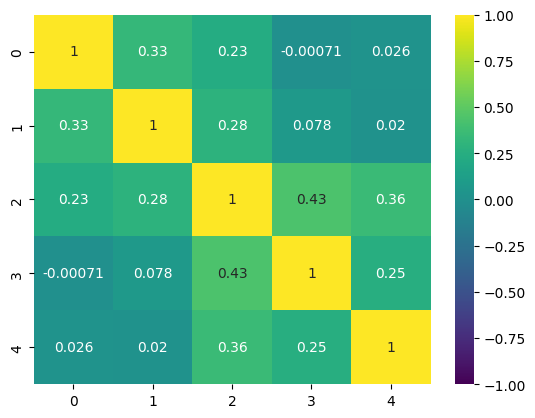

In [100]:
sns.heatmap(K, cmap='viridis', vmin=-1, vmax=1, annot=True)
plt.savefig("img/P1I_heatmap_K")
plt.show()

In [108]:
K_df = pd.DataFrame(K, columns=['mechanics', 'vectors','algebra','analysis','statistics'])
G = nx.Graph()
G.add_nodes_from(K_df.columns)

# Iterate through the upper triangle of the matrix to avoid duplicate edges
for i in range(len(K_df.columns)):
    for j in range(i + 1, len(K_df.columns)):
        u = K_df.columns[i]
        v = K_df.columns[j]
        weight = K_df.iloc[i, j]
        
        # Add the edge with the partial correlation as the weight
        G.add_edge(u, v, weight=weight)

# Verification
print(f"Nodes: {G.nodes}")
print(f"Number of edges: {G.number_of_edges()}") # Should be 10 for 5 nodes

Nodes: ['mechanics', 'vectors', 'algebra', 'analysis', 'statistics']
Number of edges: 10


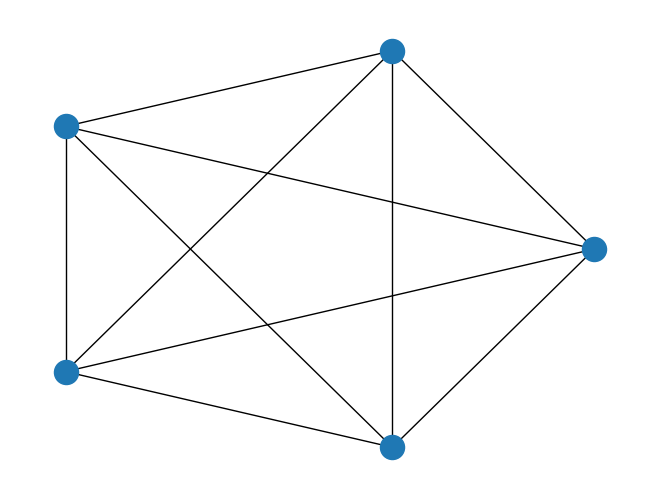

In [109]:
nx.draw_circular(G)

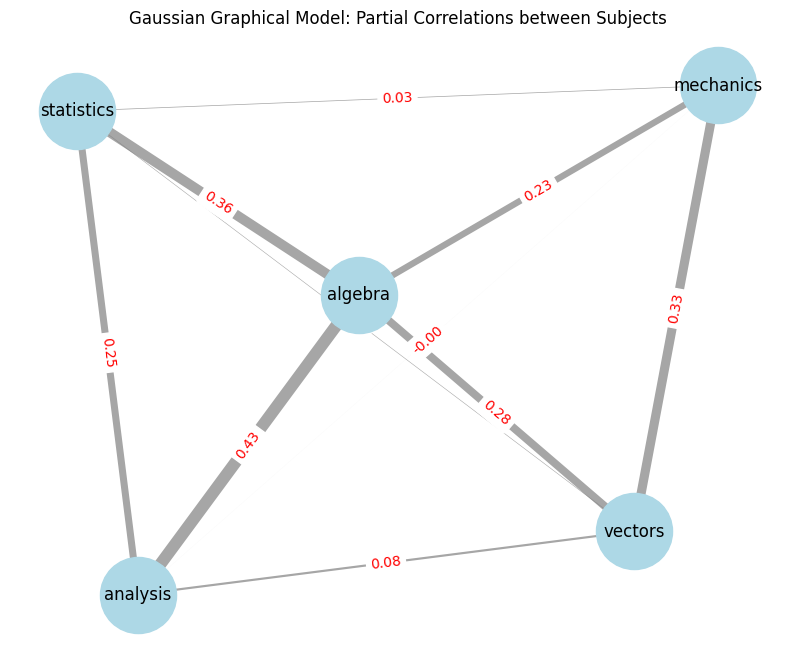

In [114]:

# 3. Define Layout
pos = nx.spring_layout(G, seed=42)  # Consistent layout

# 4. Extract weights for visualization
edges = G.edges(data=True)
weights = [abs(d['weight']) * 20 for (u, v, d) in edges] # Scale by 10 for visibility

# 5. Draw the Graph
plt.figure(figsize=(10, 8))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightblue')

# Draw edges with varying widths
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.7)

# Draw labels (Subject names)
nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")

# Draw edge labels (Partial Correlation values)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Gaussian Graphical Model: Partial Correlations between Subjects")
plt.axis('off')
plt.savefig("img/P1J_network")
plt.show()

## Problem 2 - Partial independency

In [101]:
sample_size = 1000
X = np.random.normal(0,1,sample_size)
Y = np.random.normal( [2*x +1 for x in X], 0.5, sample_size) + np.random.normal(0, 0.5, sample_size)
Z = np.random.normal( [5*x +1 for x in X], 1, sample_size) + np.random.normal(0, 0.5)


**(A)** Scatterplot matrix. Which variables are independent? 

It looks like all of them are lineary dependent.

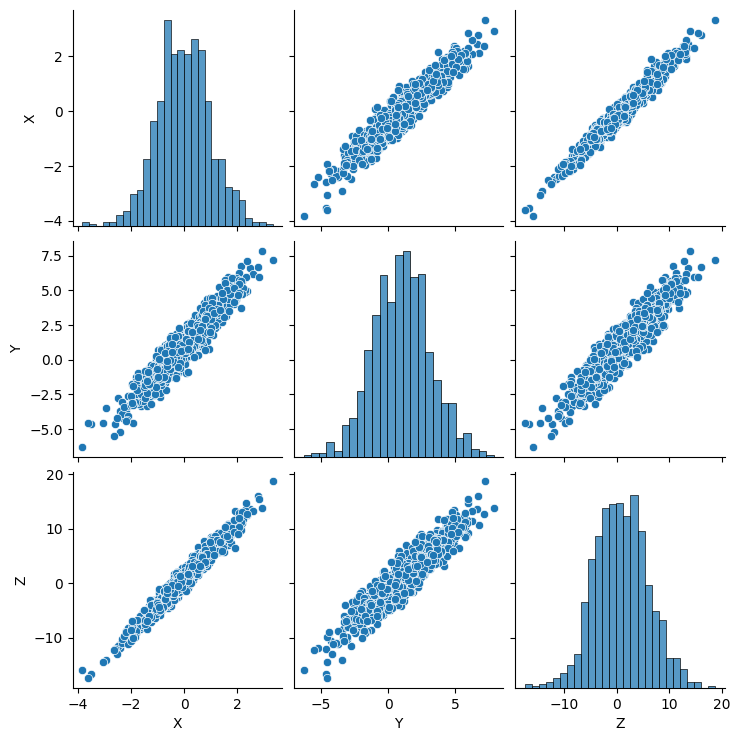

In [102]:
df = pd.DataFrame([X,Y,Z], index=['X','Y', 'Z']).T
sns.pairplot(df)
plt.savefig("img/P2A_pairplot")
plt.show()

**(B)** Correlations and heatmap. Assume dependency again.

The correlation coefficient are all over 0.9, which is sign of very strong dependency. 

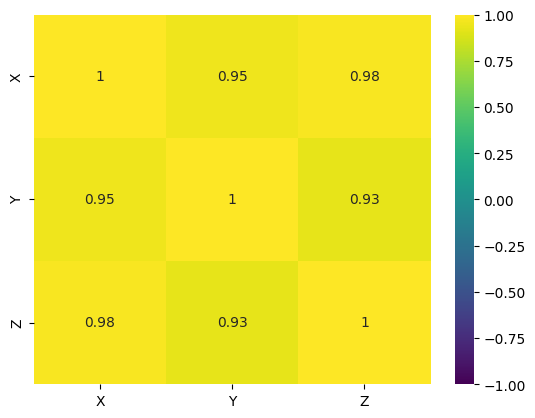

In [103]:
cor = df.corr()
sns.heatmap(cor, cmap='viridis', annot=True, vmin=-1, vmax=1)
plt.savefig("img/P2B_heatmap_raw")
plt.show()

**(C)** Compute Partial correlations:

In [104]:

def get_residulas(predictor, target):
    model = LinearRegression().fit(predictor.reshape(-1,1), target)
    predictions = model.predict(predictor.reshape(-1,1))
    residuals = target - predictions
    return residuals

res_YbyX = get_residulas(X,Y)
res_ZbyX = get_residulas(X,Z)

res_XbyY = get_residulas(Y,X)
res_ZbyY = get_residulas(Y,Z)

res_XbyZ = get_residulas(Z,X)
res_YbyZ = get_residulas(Z,Y)

print(f"Partial correlation when predictor = X is {np.corrcoef(res_YbyX, res_ZbyX)[0,1]:.4f}")
print(f"Partial correlation when predictor = Y is {np.corrcoef(res_XbyY, res_ZbyY)[0,1]:.4f}")
print(f"Partial correlation when predictor = Z is {np.corrcoef(res_XbyZ, res_YbyZ)[0,1]:.4f}")


Partial correlation when predictor = X is -0.0190
Partial correlation when predictor = Y is 0.8606
Partial correlation when predictor = Z is 0.4978


**(D)** Compute partial correlation based on the inverse of the covariance matrix. Rescale and compare with (C).

We see it's exactly the same.

In [105]:
cov = df.cov()
cov_inv = np.linalg.inv(cov)
cov_inv_scaled = np.zeros_like(cov_inv)
for i in range(len(cov_inv)):
    for j in range(len(cov_inv[0])):
        if i!=j:
            cov_inv_scaled[i,j] = - cov_inv[i,j] / np.sqrt(cov_inv[i,i]*cov_inv[j,j])
        else:
            cov_inv_scaled[i,j]=1

print(cov_inv_scaled)

print(f"Partial correlation when predictor = X is {cov_inv_scaled[1,2]:.4f}")
print(f"Partial correlation when predictor = Y is {cov_inv_scaled[0,2]:.4f}")
print(f"Partial correlation when predictor = Z is {cov_inv_scaled[0,1]:.4f}")

[[ 1.          0.49781912  0.86060316]
 [ 0.49781912  1.         -0.01898914]
 [ 0.86060316 -0.01898914  1.        ]]
Partial correlation when predictor = X is -0.0190
Partial correlation when predictor = Y is 0.8606
Partial correlation when predictor = Z is 0.4978


**(E)** Plot a heatmap of partial correlations. Compare with classic correlations. Which variables are conditionally independent?

By Partial Correlation we got rid of indirect dependency of Y,Z. In other words, we can satisfibly explain variable Z and Y solely by X. 

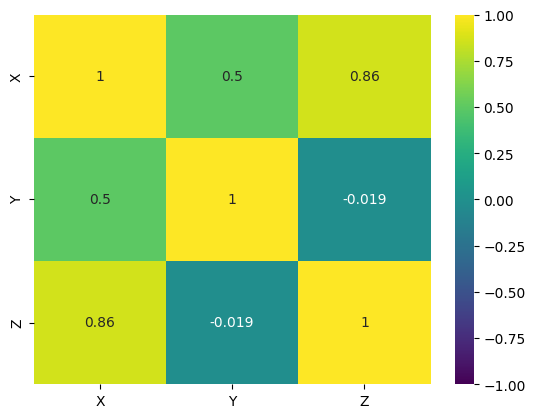

In [106]:
df_partial_corr = pd.DataFrame(cov_inv_scaled, columns=['X','Y','Z'], index=['X','Y','Z'])
sns.heatmap(df_partial_corr, cmap="viridis", vmin=-1, vmax=1, annot=True)
plt.savefig("img/P2E_heatmap_partial_corr")
plt.show()